# Experiment Notebook
- This notebook contains:
  1. Dataset download
  2. Data representation (sparse + embeddings)
  3. EDA
  4. Saving extracted features for other scripts

## Imports

In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

## Downloading the dataset

In [4]:
dataset = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
from datasets import concatenate_datasets
from sklearn.model_selection import train_test_split

full = concatenate_datasets([dataset["train"], dataset["test"]])
full = full.shuffle(seed=42).select(range(8000))

texts  = list(full["text"])
labels = np.array(full["label"])

X_train_docs, X_test_docs, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

y_train = np.array(y_train)
y_test  = np.array(y_test)

## Data Representation

### A. Sparse Features

- Includes BoW and TF-IDF feature extraction
- We have included our own implementation of certain key functions to show clarity in concepts being used.
- The feature extraction uses sci-kit learn implementation

#### From-the-scratch Implementation

In [6]:
def clean_html(text):
    return re.sub(r'<.*?>', ' ', text)

def tokenize(text, mode='unigram'):
    text = text.lower()
    text = clean_html(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and t]

    if mode == 'unigram':
        return tokens

    elif mode == 'bigram':
        bigrams = [tokens[i] + "_" + tokens[i+1] for i in range(len(tokens)-1)]
        return bigrams

    elif mode == 'both':
        bigrams = [tokens[i] + "_" + tokens[i+1] for i in range(len(tokens)-1)]
        return tokens + bigrams
    else:
       raise ValueError("mode is not in {'unigram', 'bigram', 'both'}")


def bowdict(docs, mode='unigram'):
  d = {}
  x = 0
  for i in docs:
    i = tokenize(i, mode)
    for j in i:
      if j not in d:
        d[j] = x
        x+= 1
  return d

def bow_vectorize(doc, vocab, mode='unigram'):
    vec = np.zeros(len(vocab))
    for word in tokenize(doc, mode):
        if word in vocab:
          vec[vocab[word]] += 1

    return vec

def bow_matrix(docs, mode='unigram'):
    vocab = bowdict(docs, mode)
    matrix = np.array([bow_vectorize(doc, vocab, mode) for doc in docs])
    return matrix, vocab

In [7]:
def prune_vocab(bowed, vocab, min_df=5, max_df_ratio=0.8):
    N = bowed.shape[0]
    df = (bowed > 0).sum(axis=0)

    keep = (df >= min_df) & (df <= max_df_ratio * N)

    new_vocab = {}
    new_id = 0

    for word, idx in vocab.items():
        if keep[idx]:
            new_vocab[word] = new_id
            new_id += 1

    return new_vocab, keep

def apply_pruning(bowed, keep_mask):
    return bowed[:, keep_mask]

In [8]:
def tf(bowed):
    row_sums = bowed.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return bowed / row_sums

def idf(bowed):
    N = bowed.shape[0]
    df = (bowed > 0).sum(axis=0)
    return np.log((N + 1) / (df + 1)) + 1


def build_index(docs, mode='unigram', min_df=5, max_df_ratio=0.8):
    bowed_full, vocab_full = bow_matrix(docs, mode)
    vocab, keep_mask = prune_vocab(bowed_full, vocab_full, min_df, max_df_ratio)

    bowed = apply_pruning(bowed_full, keep_mask)

    tf_bowed = tf(bowed)
    idf_vec = idf(bowed)

    tfidf_docs = tf_bowed * idf_vec

    norms = np.linalg.norm(tfidf_docs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    tfidf_docs = tfidf_docs / norms

    return tfidf_docs, vocab, idf_vec

In [9]:
def vectorize_query(query, vocab, idf_vec, mode='unigram'):
    vec = np.zeros(len(vocab))
    for word in tokenize(query, mode):
        if word in vocab:
            vec[vocab[word]] += 1

    if vec.sum() == 0:
        return vec
    tf_vec = vec / vec.sum()
    res = tf_vec * idf_vec
    norm = np.linalg.norm(res)
    if norm:
        res = res / norm
    return res

#### Sci-kit learn implementation

In [10]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# BoW
bow_vec = CountVectorizer(
    binary=True,
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 1),
)

X_bow_train = bow_vec.fit_transform(X_train_docs)
X_bow_test  = bow_vec.transform(X_test_docs)

# TF-IDF
tfidf_vec = TfidfVectorizer(
    max_features=30000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_tfidf_train = tfidf_vec.fit_transform(X_train_docs)
X_tfidf_test  = tfidf_vec.transform(X_test_docs)

### B. Embeddings
- We are using DistilBERT

In [11]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.to(device)
model.eval()  # VERY IMPORTANT (disables dropout)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [12]:
def get_embeddings(texts, batch_size=32, max_length=256, pooling="cls"):
    all_embeddings = []

    with torch.no_grad():  # ensures no gradients
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]

            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)
            hidden_states = outputs.last_hidden_state  # (B, T, H)

            if pooling == "cls":
                # DistilBERT doesn't have CLS token explicitly, use first token
                embeddings = hidden_states[:, 0, :]  # (B, H)

            elif pooling == "mean":
                attention_mask = encoded["attention_mask"].unsqueeze(-1)
                masked = hidden_states * attention_mask
                summed = masked.sum(dim=1)
                counts = attention_mask.sum(dim=1)
                counts = torch.clamp(counts, min=1)
                embeddings = summed / counts

            else:
                raise ValueError("pooling must be 'cls' or 'mean'")

            all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [13]:
X_train_emb = get_embeddings(X_train_docs, pooling="mean")
X_test_emb  = get_embeddings(X_test_docs, pooling="mean")

100%|██████████| 50/50 [00:12<00:00,  4.12it/s]


**bold text**## EDA

## EDA

### For Sparse Feature Representation

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

/tmp/ipykernel_4095/1851298496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette="Set2")


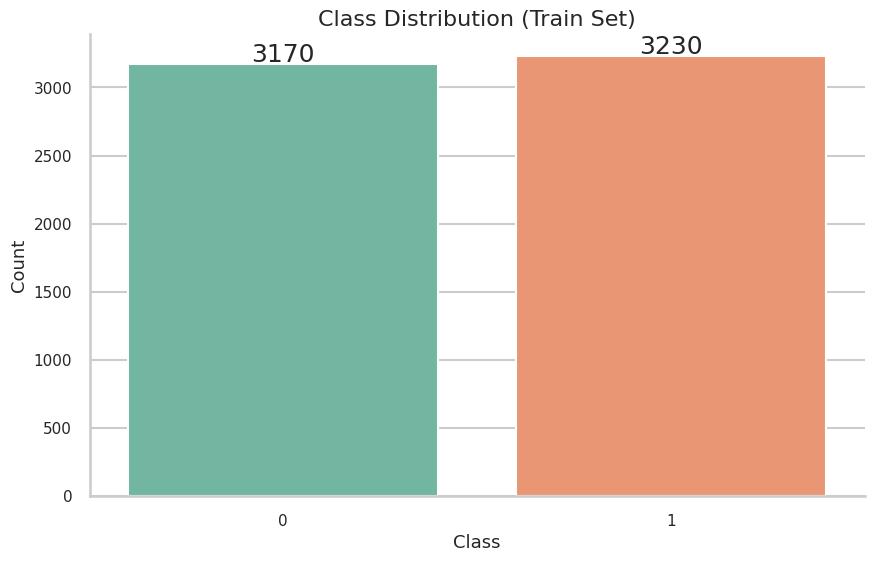

In [15]:
classes, counts = np.unique(y_train, return_counts=True)

sns.barplot(x=classes, y=counts, palette="Set2")

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Train Set)")

for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center')

sns.despine()
plt.show()

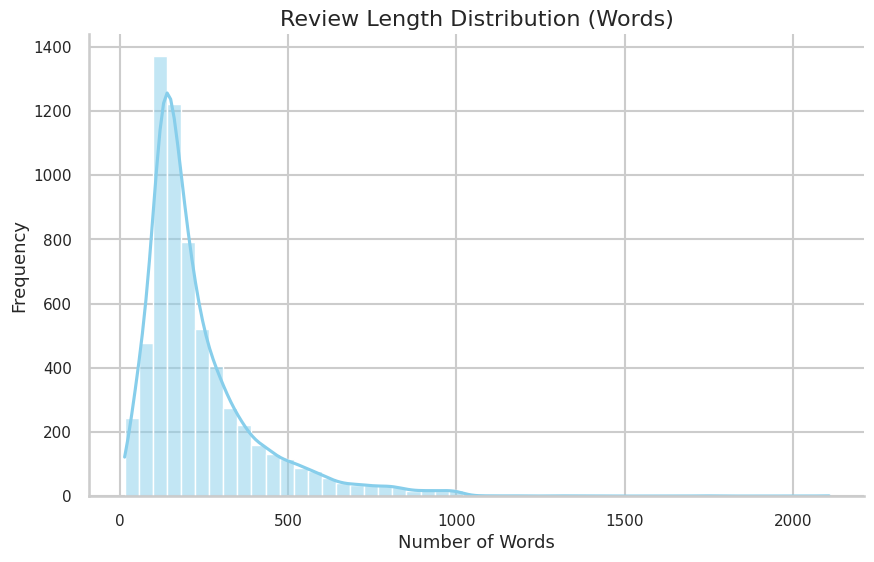

In [16]:
document_lengths = [len(doc.split()) for doc in X_train_docs]

sns.histplot(document_lengths, bins=50, kde=True, color="skyblue")

plt.title("Review Length Distribution (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

sns.despine()
plt.show()

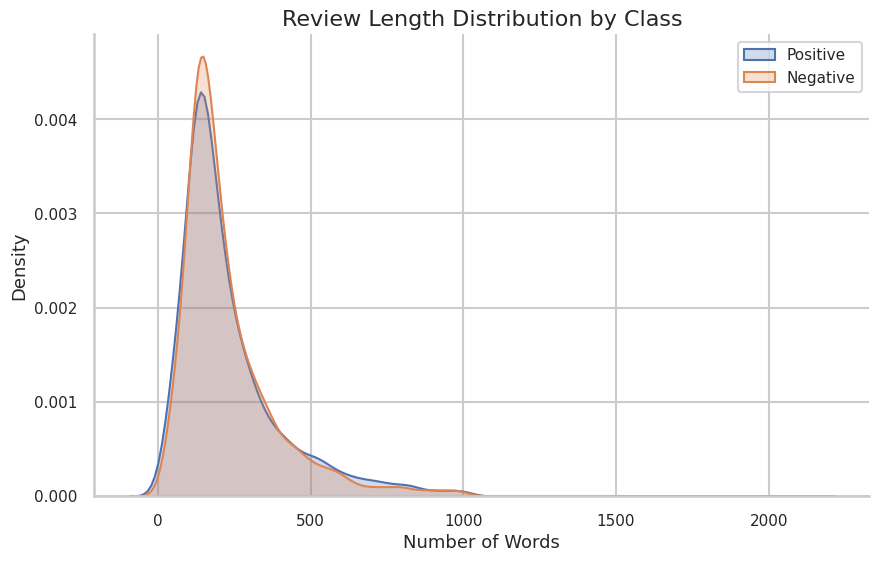

In [17]:
pos_lengths = [len(doc.split()) for doc, y in zip(X_train_docs, y_train) if y == 1]
neg_lengths = [len(doc.split()) for doc, y in zip(X_train_docs, y_train) if y == 0]

sns.kdeplot(pos_lengths, label="Positive", fill=True)
sns.kdeplot(neg_lengths, label="Negative", fill=True)

plt.title("Review Length Distribution by Class")
plt.xlabel("Number of Words")
plt.legend()
sns.despine()
plt.show()

In [18]:
tokenized_docs_unigram = [tokenize(doc, mode='unigram') for doc in X_train_docs]
tokenized_docs_bigram  = [tokenize(doc, mode='bigram') for doc in X_train_docs]

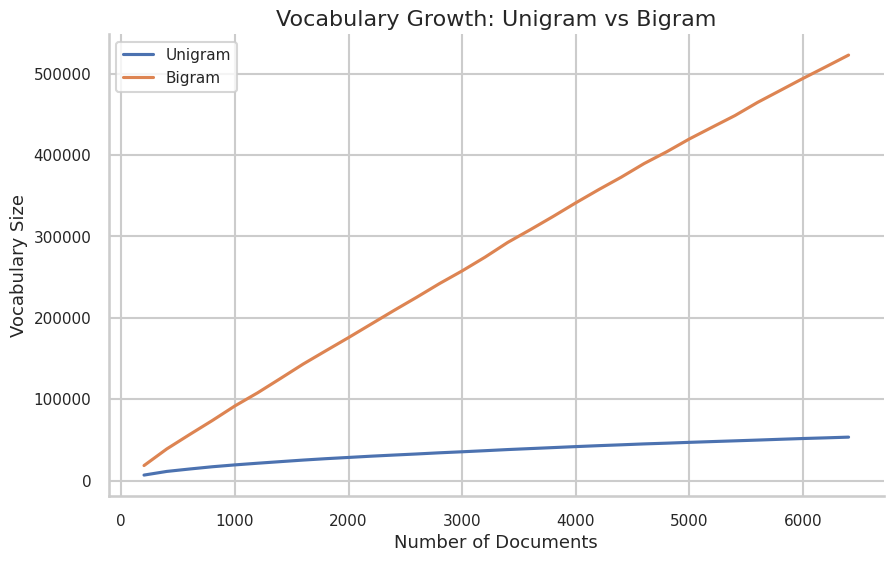

In [19]:
def compute_vocab_growth(tokenized_docs, step=200):
    vocab = set()
    vocab_sizes = []
    num_docs = []

    for i, tokens in enumerate(tokenized_docs):
        vocab.update(tokens)

        if (i + 1) % step == 0:
            num_docs.append(i + 1)
            vocab_sizes.append(len(vocab))

    return num_docs, vocab_sizes


num_docs, vocab_unigram = compute_vocab_growth(tokenized_docs_unigram)
_, vocab_bigram = compute_vocab_growth(tokenized_docs_bigram)

sns.lineplot(x=num_docs, y=vocab_unigram, label="Unigram")
sns.lineplot(x=num_docs, y=vocab_bigram, label="Bigram")

plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Growth: Unigram vs Bigram")

sns.despine()
plt.show()

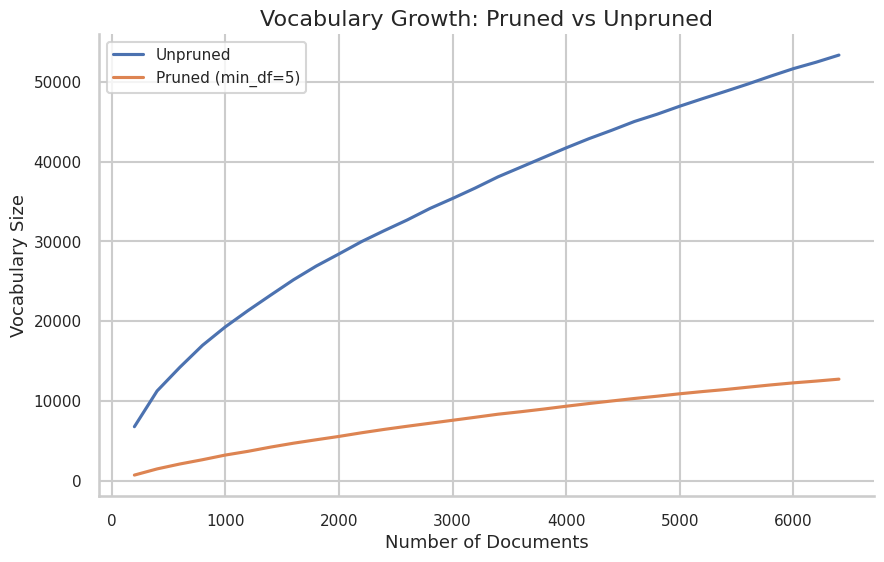

In [20]:
from collections import defaultdict

vocab = set()
df_counts = defaultdict(int)

vocab_sizes = []
pruned_sizes = []
num_docs = []

step = 200
min_df = 5

for i, tokens in enumerate(tokenized_docs_unigram):
    unique_tokens = set(tokens)
    vocab.update(unique_tokens)

    for t in unique_tokens:
        df_counts[t] += 1

    if (i + 1) % step == 0:
        num_docs.append(i + 1)

        vocab_sizes.append(len(vocab))
        pruned_vocab = [t for t in vocab if df_counts[t] >= min_df]
        pruned_sizes.append(len(pruned_vocab))

sns.lineplot(x=num_docs, y=vocab_sizes, label="Unpruned")
sns.lineplot(x=num_docs, y=pruned_sizes, label=f"Pruned (min_df={min_df})")

plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Growth: Pruned vs Unpruned")

sns.despine()
plt.show()

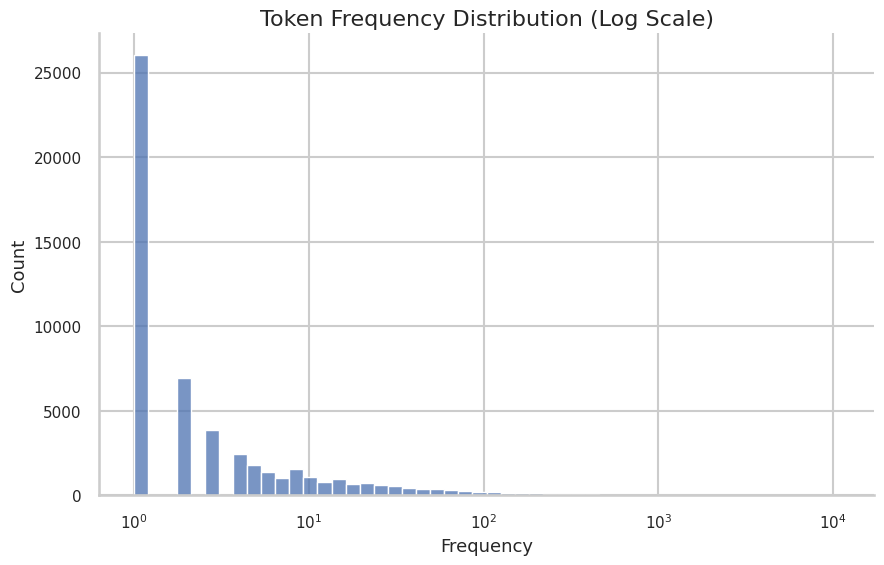

In [21]:
from collections import Counter

all_tokens = []
for doc in tokenized_docs_unigram:
    all_tokens.extend(doc)

counter = Counter(all_tokens)
freqs = np.array(list(counter.values()))

sns.histplot(freqs, bins=50, log_scale=True)

plt.title("Token Frequency Distribution (Log Scale)")
plt.xlabel("Frequency")
plt.ylabel("Count")

sns.despine()
plt.show()

/tmp/ipykernel_4095/2796879872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette="Blues_r")


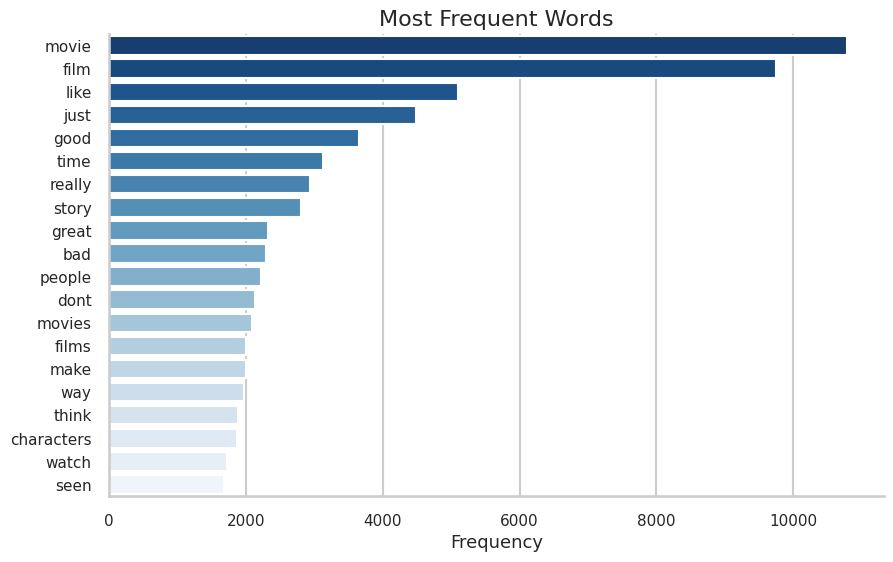

In [22]:
common_words = counter.most_common(20)

words = [w for w, _ in common_words]
counts = [c for _, c in common_words]

sns.barplot(x=counts, y=words, palette="Blues_r")

plt.title("Most Frequent Words")
plt.xlabel("Frequency")

sns.despine()
plt.show()

#### Finding Positive and Negative Words

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    preprocessor=lambda x: re.sub(r'<.*?>', ' ', x.lower()),
    stop_words='english',
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8,
)

X_tfidf = vectorizer.fit_transform(X_train_docs)

X_pos = X_tfidf[y_train == 1]
X_neg = X_tfidf[y_train == 0]

mean_pos = np.asarray(X_pos.mean(axis=0)).ravel()
mean_neg = np.asarray(X_neg.mean(axis=0)).ravel()

feature_names = np.array(vectorizer.get_feature_names_out())

top_k = 20

top_pos_idx = np.argsort(mean_pos)[-top_k:][::-1]
top_neg_idx = np.argsort(mean_neg)[-top_k:][::-1]

sparsity = 1.0 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print(f"TF-IDF Sparsity: {sparsity:.4f}")

TF-IDF Sparsity: 0.9937


TF-IDF has very high sparsity (~99.37%)

/tmp/ipykernel_4095/477265752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


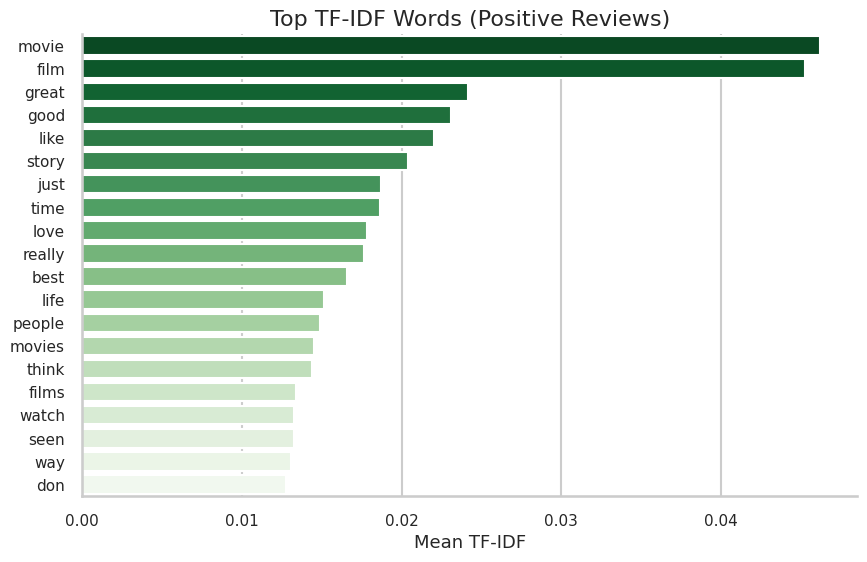

/tmp/ipykernel_4095/477265752.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


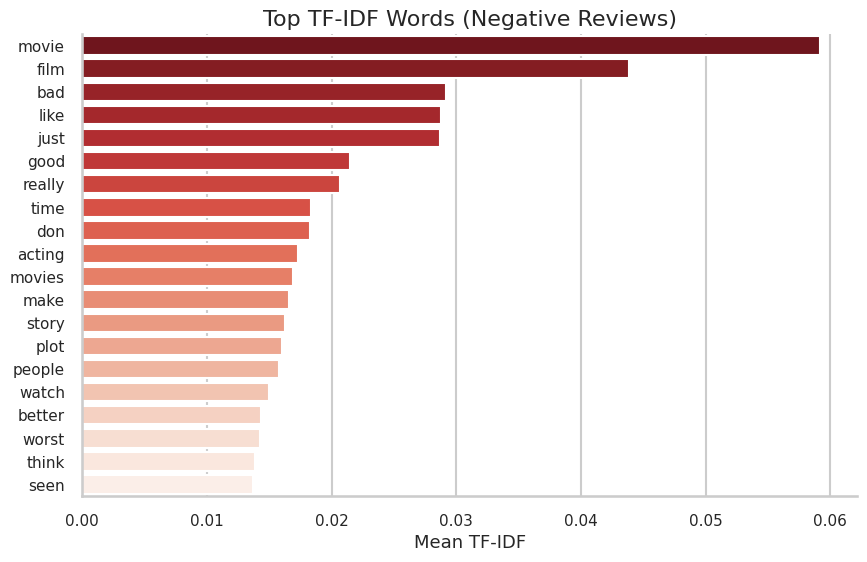

In [28]:
# Positive
sns.barplot(
    x=mean_pos[top_pos_idx],
    y=feature_names[top_pos_idx],
    palette="Greens_r"
)

plt.title("Top TF-IDF Words (Positive Reviews)")
plt.xlabel("Mean TF-IDF")

sns.despine()
plt.show()


# Negative
sns.barplot(
    x=mean_neg[top_neg_idx],
    y=feature_names[top_neg_idx],
    palette="Reds_r"
)

plt.title("Top TF-IDF Words (Negative Reviews)")
plt.xlabel("Mean TF-IDF")

sns.despine()
plt.show()

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

* Notice how words like `movie` and `film` appear as top elements in both positive and negative reviews. This is because they have high frequency (TF) and do not appear in all documnets (mid-low DF), irrespective of which class the reviews belong to.
* In order to remove this form of bias, we can find the difference between `mean_pos` and `mean_neg` instead of using only one of them.
* Below is a visual depiction of the most important words in each class after this method is used

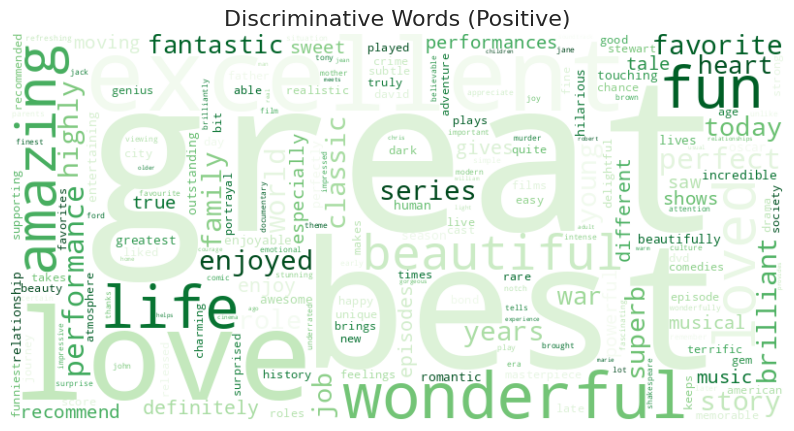

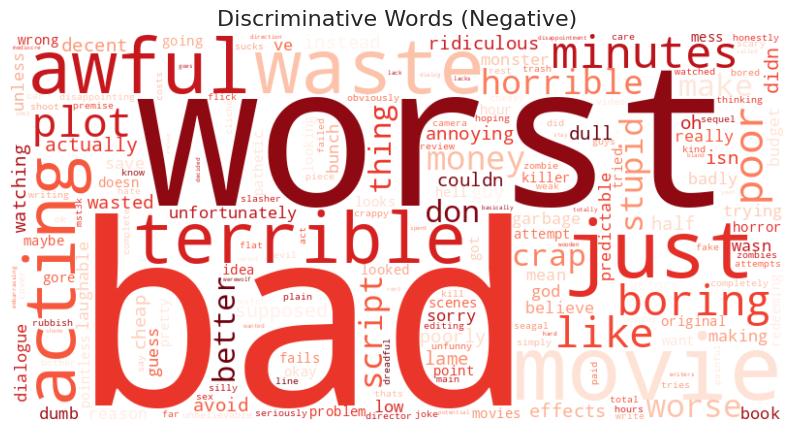

In [26]:
diff = mean_pos - mean_neg

# Positive cloud
pos_scores = {w: s for w, s in zip(feature_names, diff) if s > 0}

# Negative cloud
neg_scores = {w: -s for w, s in zip(feature_names, diff) if s < 0}

wc_diff = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate_from_frequencies(pos_scores)

plt.imshow(wc_diff, interpolation='bilinear')
plt.axis('off')
plt.title("Discriminative Words (Positive)")
plt.show()

wc_diff = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate_from_frequencies(neg_scores)

plt.imshow(wc_diff, interpolation='bilinear')
plt.axis('off')
plt.title("Discriminative Words (Negative)")
plt.show()

### For Embedding Representation

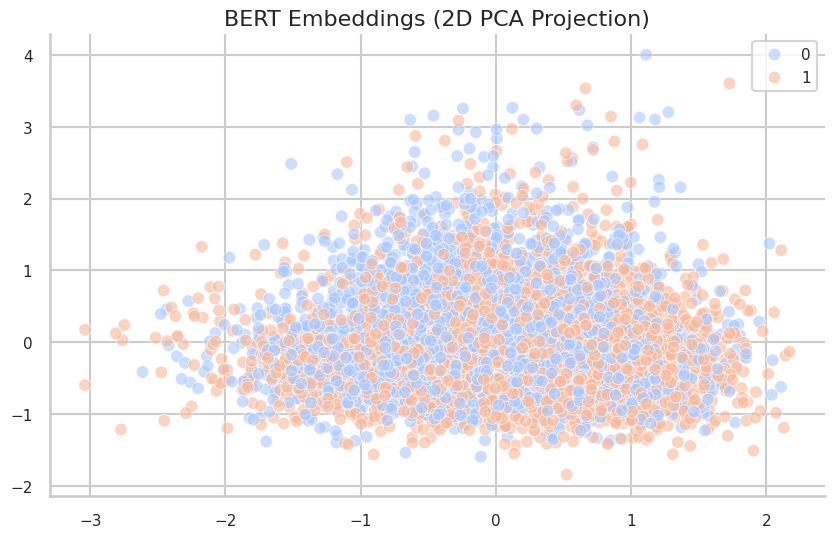

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_emb)

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=y_train,
    palette="coolwarm",
    alpha=0.6
)

plt.title("BERT Embeddings (2D PCA Projection)")
sns.despine()
plt.show()

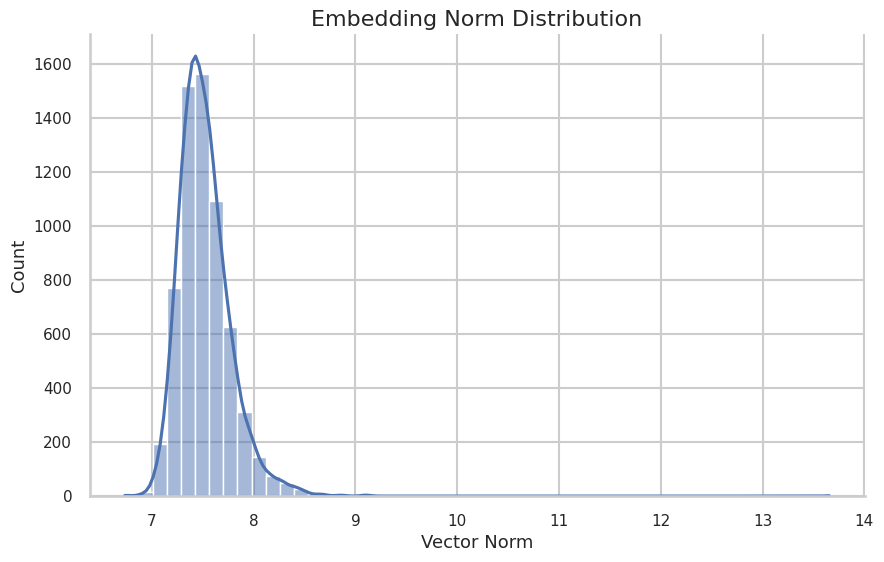

In [31]:
norms = np.linalg.norm(X_train_emb, axis=1)

sns.histplot(norms, bins=50, kde=True)

plt.title("Embedding Norm Distribution")
plt.xlabel("Vector Norm")
sns.despine()
plt.show()

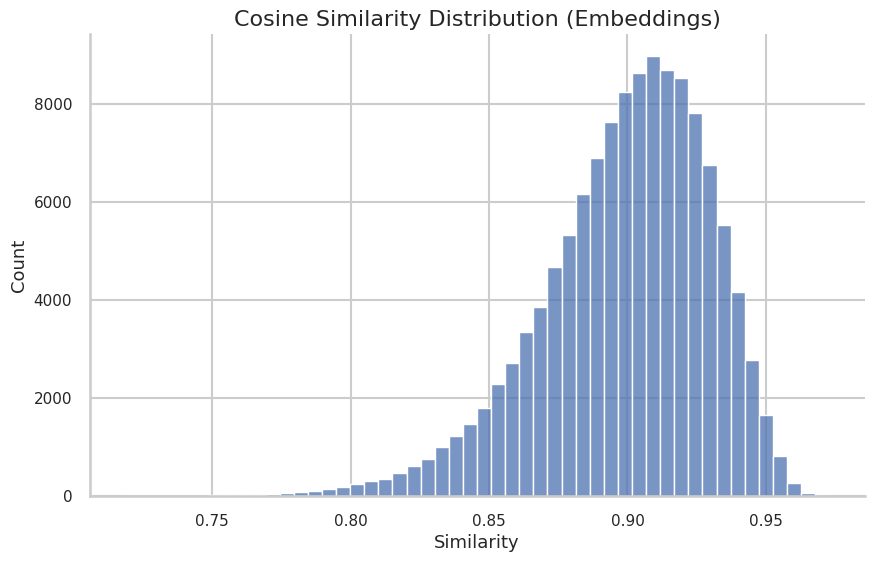

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

# sample for speed
idx = np.random.choice(len(X_train_emb), size=500, replace=False)
sample = X_train_emb[idx]

sim_matrix = cosine_similarity(sample)

# take upper triangle (avoid duplicates)
sims = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

sns.histplot(sims, bins=50)

plt.title("Cosine Similarity Distribution (Embeddings)")
plt.xlabel("Similarity")
sns.despine()
plt.show()

In [ ]:
from sklearn.manifold import TSNE

idx = np.random.choice(len(X_train_emb), size=1000, replace=False)
X_sample = X_train_emb[idx]
y_sample = y_train[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)


plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_sample,
    palette="coolwarm",
    alpha=0.7
)

plt.title("t-SNE Projection of BERT Embeddings")
sns.despine()

# save
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=300)

plt.show()

## Saving features

In [ ]:
from scipy.sparse import save_npz
import pickle

np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)


save_npz("X_bow_train.npz", X_bow_train)
save_npz("X_bow_test.npz",  X_bow_test)

save_npz("X_tfidf_train.npz", X_tfidf_train)
save_npz("X_tfidf_test.npz",  X_tfidf_test)


np.save("X_train_emb_mean.npy", X_train_emb)
np.save("X_test_emb_mean.npy",  X_test_emb)


with open("bow_vectorizer.pkl", "wb") as f:
    pickle.dump(bow_vec, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vec, f)

np.save("tfidf_feature_names.npy", tfidf_vec.get_feature_names_out())

import pickle

with open("X_train_raw.pkl", "wb") as f:
    pickle.dump(X_train_docs, f)

with open("X_test_raw.pkl", "wb") as f:
    pickle.dump(X_test_docs, f)

print("All features saved successfully.")

All features saved successfully.


In [ ]:
import os
import zipfile
from google.colab import files

FEATURE_DIR = "features"   # change if needed
ZIP_NAME = "features.zip"

# Create zip
with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files_in_dir in os.walk(FEATURE_DIR):
        for file in files_in_dir:
            filepath = os.path.join(root, file)
            zipf.write(filepath, arcname=os.path.relpath(filepath, FEATURE_DIR))

print(f"{ZIP_NAME} created successfully!")

# Download
files.download(ZIP_NAME)


features.zip created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>